# Hola &#x1F600;,

Soy **Hesus Garcia** – **"Soy el único Hesus que conoces (y probablemente conocerás) 🌟"** – Sí, como "Jesús", pero con una H que me hace único. Puede sonar raro, pero créeme, ¡no lo olvidarás! Como tu revisor en Triple-Ten, estoy aquí para guiarte y ayudarte a mejorar tu código. Si algo necesita un ajuste, no hay de qué preocuparse; ¡aquí estoy para hacer que tu trabajo brille con todo su potencial! ✨

Cada vez que encuentre un detalle importante en tu código, te lo señalaré para que puedas corregirlo y así te prepares para un ambiente de trabajo real, donde el líder de tu equipo actuaría de manera similar. Si en algún momento no logras solucionar el problema, te daré más detalles para ayudarte en nuestra próxima oportunidad de revisión.

Es importante que cuando encuentres un comentario, **no los muevas, no los modifiques, ni los borres**.

---

### Formato de Comentarios

Revisaré cuidadosamente cada implementación en tu notebook para asegurar que cumpla con los requisitos y te daré comentarios de acuerdo al siguiente formato:


<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class="tocSkip"></a><br>
    
<b>Éxito</b> - ¡Excelente trabajo! Esta parte está bien implementada y contribuye significativamente al análisis de datos o al proyecto. Continúa aplicando estas buenas prácticas en futuras secciones.
    
</div>

<div class="alert alert-block alert-warning">
<b>Comentario del revisor</b> <a class="tocSkip"></a><br>
    
<b>Atención</b> ⚠️ - Este código está correcto, pero se puede optimizar. Considera implementar mejoras para que sea más eficiente y fácil de leer. Esto fortalecerá la calidad de tu proyecto.
    
</div>

<div class="alert alert-block alert-danger">
<b>Comentario del revisor</b> <a class="tocSkip"></a><br>
    
<b>A resolver</b> ❗ - Aquí hay un problema o error en el código que es necesario corregir para aprobar esta sección. Por favor, revisa y corrige este punto, ya que es fundamental para la validez del análisis y la precisión de los resultados.
    
</div>

---

Al final de cada revisión, recibirás un **Comentario General del Revisor** que incluirá:

- **Aspectos positivos:** Un resumen de los puntos fuertes de tu proyecto.
- **Áreas de mejora:** Sugerencias sobre aspectos donde puedes mejorar.
- **Temas adicionales para investigar:** Ideas de temas opcionales que puedes explorar por tu cuenta para desarrollar aún más tus habilidades.

Estos temas adicionales no son obligatorios en esta etapa, pero pueden serte útiles para profundizar en el futuro.

---


Esta estructura en viñetas facilita la lectura y comprensión de cada parte del comentario final.

También puedes responderme de la siguiente manera si tienes alguna duda o quieres aclarar algo específico:


<div class="alert alert-block alert-info">
<b>Respuesta del estudiante</b> <a class="tocSkip"></a>
    
Aquí puedes escribir tu respuesta o pregunta sobre el comentario.
    
</div>


**¡Empecemos!** &#x1F680;


# Comentario General del Revisor - 1a iteración

<div class="alert alert-block alert-success">
<b>Comentario del revisor - 1a iteración</b> <a class="tocSkip"></a><br><br>

El proyecto demuestra un buen dominio del flujo completo de un problema de clasificación, desde la preparación de los datos hasta la interpretación del modelo en términos de negocio.

<br><br>

<b>Puntos positivos:</b>

<ul>
<li>Integraste correctamente las distintas fuentes y justificaste el tratamiento de valores ausentes.</li>
<li>Construiste adecuadamente la variable objetivo y preparaste las variables categóricas y numéricas para el modelado.</li>
<li>Estableciste modelos baseline y los utilizaste como referencia para medir el impacto de la optimización.</li>
<li>La optimización con LightGBM consiguió mantener un AUC-ROC de aproximadamente 0.84 y aumentar el Recall hasta 0.80, superando ampliamente el criterio mínimo del proyecto.</li>
<li>El informe final traduce correctamente el Recall a un escenario comprensible para marketing, mostrando que el modelo puede identificar aproximadamente 4 de cada 5 clientes que terminarán abandonando.</li>
</ul>


<b>El proyecto está aprobado.</b>

</div>


# Proyecto Final: Predicción de Fuga de Clientes — Interconnect

El operador de telecomunicaciones **Interconnect** busca reducir la cancelación de clientes (`Churn`) mediante un sistema que identifique con anticipación a quienes podrían darse de baja, para ofrecerles promociones y planes especiales.

**Objetivo:** Desarrollar y comparar modelos capaces de predecir si un cliente se dará de baja próximamente (Sí/No).

- El modelo se evaluará principalmente con **AUC-ROC** (objetivo > 0.75) y con **Recall** como métrica adicional.



## Etapa 1: Plan de Trabajo



**1. Unión de datos y valores nulos**

`contract.csv` es la tabla base (7,043 clientes, todos los que existen). `internet.csv` (5,517) y `phone.csv` (6,361) son subconjuntos, por ende no todos los clientes tienen ambos servicios. Haré un left merge de `personal`, `internet` y `phone` sobre `contract` usando `customerID`.

Los nulos que se generan en las columnas de `internet` (7 columnas: InternetService, OnlineSecurity, etc.) y `phone` (MultipleLines) para los clientes que no tienen ese servicio los rellenaré con "No". No es un error de captura, es que el cliente simplemente no contrató ese servicio, así el modelo lo puede interpretar como una categoría real ("no tiene DSL/fibra", "no tiene líneas múltiples").

También encontré 11 filas con `TotalCharges` vacío que corresponden a clientes que se dieron de alta el mismo día que se extrajo el dataset (`BeginDate = 2020-02-01`, la fecha máxima registrada), o sea aún no se les ha facturado un ciclo completo. Los rellenaré con 0.

**2. Variable objetivo**

Es un problema de clasificación binaria. Creo `Churn: 1 si EndDate != "No"` (tiene fecha de baja), 0 si EndDate == "No" (sigue activo). La tasa de fuga real es de 26.5% por lo que hay desbalance de clases, que abordaré luego.

**3. Preprocesamiento**

-`BeginDate/EndDate` pasan de texto a fecha. Como no tengo fecha "de hoy" real, uso 2020-02-01 (la fecha máxima de extracción del dataset) como fecha de referencia para los clientes activos. Con esto calculo `tenure` (antigüedad en meses) = variable numérica clave, y descarto las fechas crudas para evitar fuga de información (`EndDate` define directamente el target).

-Variables categóricas binarias (Yes/No, género) en codificación 0/1.

-Variables categóricas nominales (Type, PaymentMethod, InternetService) pasando a One-Hot Encoding.

-`customerID` se descarta del modelado (es solo identificador).

**4. Modelos a entrenar**

-`Baseline` (sin balanceo): Regresión Logística y Random Forest haciendo referencia rápida de qué tan separables son las clases.

-`Optimizado`: LightGBM (maneja bien variables categóricas y desbalance nativo vía `class_weight/scale_pos_weight`) + Random Forest con class_weight='balanced', con búsqueda de hiperparámetros (RandomizedSearchCV) y comparando también con upsampling de la clase minoritaria.

-Métrica principal: AUC-ROC (objetivo > 0.75, ideal > 0.88). Métrica secundaria: Recall.

<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class="tocSkip"></a><br>

<b>Éxito</b> - El plan de trabajo está bien estructurado y demuestra una comprensión clara del problema: identificas correctamente la tabla base y el tipo de unión, justificas los nulos derivados de la ausencia de servicios, defines adecuadamente el objetivo de clasificación binaria y propones una estrategia coherente de codificación, ingeniería de características y comparación entre modelos baseline y optimizados.


</div>


## Etapa 2: Código de Solución



### 1. Exploración de Datos (EDA)

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, recall_score, f1_score, confusion_matrix, RocCurveDisplay
from lightgbm import LGBMClassifier

RANDOM_STATE = 12345
REF_DATE = pd.Timestamp('2020-02-01')  # fecha máxima de BeginDate = fecha de extracción del dataset

pd.set_option('display.max_columns', None)

In [3]:
contract = pd.read_csv('/datasets/final_provider/contract.csv')
personal = pd.read_csv('/datasets/final_provider/personal.csv')
internet = pd.read_csv('/datasets/final_provider/internet.csv')
phone = pd.read_csv('/datasets/final_provider/phone.csv')

for name, d in [('contract', contract), ('personal', personal), ('internet', internet), ('phone', phone)]:
    print(name, d.shape)

contract (7043, 8)
personal (7043, 5)
internet (5517, 8)
phone (6361, 2)


In [4]:
contract.info()
contract.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   BeginDate         7043 non-null   object 
 2   EndDate           7043 non-null   object 
 3   Type              7043 non-null   object 
 4   PaperlessBilling  7043 non-null   object 
 5   PaymentMethod     7043 non-null   object 
 6   MonthlyCharges    7043 non-null   float64
 7   TotalCharges      7043 non-null   object 
dtypes: float64(1), object(7)
memory usage: 440.3+ KB


,customerID,BeginDate,EndDate,Type,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
0,7590-VHVEG,2020-01-01,No,Month-to-month,Yes,Electronic check,29.85,29.85
1,5575-GNVDE,2017-04-01,No,One year,No,Mailed check,56.95,1889.5
2,3668-QPYBK,2019-10-01,2019-12-01 00:00:00,Month-to-month,Yes,Mailed check,53.85,108.15
3,7795-CFOCW,2016-05-01,No,One year,No,Bank transfer (automatic),42.30,1840.75
4,9237-HQITU,2019-09-01,2019-11-01 00:00:00,Month-to-month,Yes,Electronic check,70.70,151.65


In [5]:
# TotalCharges se cargó como texto,toca revisar por qué
non_numeric = contract[pd.to_numeric(contract['TotalCharges'], errors='coerce').isna()]
non_numeric[['customerID', 'BeginDate', 'EndDate', 'MonthlyCharges', 'TotalCharges']]

,customerID,BeginDate,EndDate,MonthlyCharges,TotalCharges
488,4472-LVYGI,2020-02-01,No,52.55,
753,3115-CZMZD,2020-02-01,No,20.25,
936,5709-LVOEQ,2020-02-01,No,80.85,
1082,4367-NUYAO,2020-02-01,No,25.75,
1340,1371-DWPAZ,2020-02-01,No,56.05,
3331,7644-OMVMY,2020-02-01,No,19.85,
3826,3213-VVOLG,2020-02-01,No,25.35,
4380,2520-SGTTA,2020-02-01,No,20.00,
5218,2923-ARZLG,2020-02-01,No,19.70,
6670,4075-WKNIU,2020-02-01,No,73.35,


Los 11 registros con `TotalCharges` vacío corresponden todos a clientes con `BeginDate = 2020-02-01` (la fecha más reciente del dataset) y `EndDate = "No"`: son altas nuevas que aún no completan un ciclo de facturación. Se tratarán como `TotalCharges = 0`.

0    0.735
1    0.265
Name: EndDate, dtype: float64


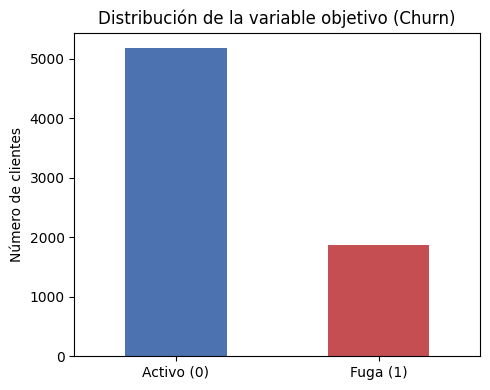

In [6]:
# Distribución de la variable objetivo (a partir de EndDate)
churn_preview = (contract['EndDate'] != 'No').astype(int)
print(churn_preview.value_counts(normalize=True).round(3))

fig, ax = plt.subplots(figsize=(5, 4))
churn_preview.value_counts().sort_index().plot(kind='bar', ax=ax, color=['#4C72B0', '#C44E52'])
ax.set_xticklabels(['Activo (0)', 'Fuga (1)'], rotation=0)
ax.set_title('Distribución de la variable objetivo (Churn)')
ax.set_ylabel('Número de clientes')
plt.tight_layout()
plt.show()

Hay un desbalance moderado: ~26.5% de los clientes se han dado de baja frente a ~73.5% activos. Se tratará en la sección de optimización.

<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class="tocSkip"></a><br>

<b>Éxito</b> - La exploración inicial está bien encaminada: cargaste correctamente las cuatro fuentes, comparaste sus dimensiones e investigaste específicamente por qué <code>TotalCharges</code> fue leído como texto. La comprobación de los 11 registros vacíos permite justificar su tratamiento, y el análisis de la variable objetivo identifica correctamente un desbalance moderado del 26.5% de clientes con fuga.

</div>


### 2. Preprocesamiento e Ingeniería de Características

In [7]:
df = contract.merge(personal, on='customerID', how='left') \
             .merge(internet, on='customerID', how='left') \
             .merge(phone, on='customerID', how='left')

print('Forma tras la unión:', df.shape)
df.isna().sum()

Forma tras la unión: (7043, 20)


customerID             0
BeginDate              0
EndDate                0
Type                   0
PaperlessBilling       0
PaymentMethod          0
MonthlyCharges         0
TotalCharges           0
gender                 0
SeniorCitizen          0
Partner                0
Dependents             0
InternetService     1526
OnlineSecurity      1526
OnlineBackup        1526
DeviceProtection    1526
TechSupport         1526
StreamingTV         1526
StreamingMovies     1526
MultipleLines        682
dtype: int64

Los nulos en las columnas de `internet` y `phone` son clientes que no contrataron ese servicio (confirmado arriba: el tamaño de cada tabla original es menor a 7,043). Se rellenan con `"No"` para que representen explícitamente la ausencia del servicio.

In [8]:
internet_cols = ['InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
                  'TechSupport', 'StreamingTV', 'StreamingMovies']
for c in internet_cols:
    df[c] = df[c].fillna('No')
df['MultipleLines'] = df['MultipleLines'].fillna('No')

df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce').fillna(0)

df.isna().sum().sum()  # confirmar que ya no quedan nulos

0

In [9]:
# Variable objetivo
df['Churn'] = (df['EndDate'] != 'No').astype(int)

# Fechas = antigüedad en meses (tenure_months)
df['BeginDate'] = pd.to_datetime(df['BeginDate'])
end_dates = pd.to_datetime(df['EndDate'], format='%Y-%m-%d %H:%M:%S', errors='coerce')  # NaT donde EndDate == 'No'
df['effective_end'] = end_dates.fillna(REF_DATE)
df['tenure_months'] = ((df['effective_end'] - df['BeginDate']).dt.days / 30.44).round().astype(int)

# Feature derivada: número de servicios de internet contratados
service_flags = [c for c in internet_cols if c != 'InternetService']
df['n_services'] = (df[service_flags] == 'Yes').sum(axis=1)

df[['BeginDate', 'EndDate', 'tenure_months', 'Churn', 'n_services']].head()

,BeginDate,EndDate,tenure_months,Churn,n_services
0,2020-01-01,No,1,0,1
1,2017-04-01,No,34,0,2
2,2019-10-01,2019-12-01 00:00:00,2,1,2
3,2016-05-01,No,45,0,3
4,2019-09-01,2019-11-01 00:00:00,2,1,0


In [10]:
# Se descartan customerID (identificador) y las fechas crudas (fuga de información directa hacia Churn)
drop_cols = ['customerID', 'BeginDate', 'EndDate', 'effective_end']
df_model = df.drop(columns=drop_cols)

binary_cols = ['PaperlessBilling', 'Partner', 'Dependents', 'gender'] + \
              [c for c in internet_cols if c != 'InternetService'] + ['MultipleLines']
nominal_cols = ['Type', 'PaymentMethod', 'InternetService']
numeric_cols = ['MonthlyCharges', 'TotalCharges', 'tenure_months', 'SeniorCitizen', 'n_services']

X = df_model.drop(columns=['Churn'])
y = df_model['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=RANDOM_STATE, stratify=y
)
print('Train:', X_train.shape, ' Test:', X_test.shape)
print('Tasa de churn train/test:', y_train.mean().round(3), y_test.mean().round(3))

Train: (5282, 19)  Test: (1761, 19)
Tasa de churn train/test: 0.265 0.265


In [11]:

preprocessor = ColumnTransformer(transformers=[
    ("num", StandardScaler(), numeric_cols),
    ("bin", OneHotEncoder(drop="if_binary"), binary_cols),  # categorías fijas Yes/No, no requiere handle_unknown
    ("nom", OneHotEncoder(handle_unknown="ignore"), nominal_cols),
])

<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class="tocSkip"></a><br>

<b>Éxito</b> - El preprocesamiento responde correctamente a lo solicitado en la tarea. Integraste las cuatro fuentes conservando los 7,043 clientes, trataste los valores ausentes de acuerdo con el significado de la ausencia de cada servicio y convertiste <code>TotalCharges</code> a un formato numérico adecuado.



</div>


### 3. Selección de Variables y Entrenamiento de Modelos (Baseline)

Se entrenan dos modelos distintos, sin ninguna técnica de balanceo de clases, como punto de referencia.

In [12]:

lr_pipe = Pipeline([
    ('prep', preprocessor),
    ('clf', LogisticRegression(max_iter=1000, random_state=RANDOM_STATE))
])
lr_pipe.fit(X_train, y_train)
lr_proba = lr_pipe.predict_proba(X_test)[:, 1]
lr_pred = lr_pipe.predict(X_test)

print('--- Baseline: Regresión Logística ---')
print('AUC-ROC:', round(roc_auc_score(y_test, lr_proba), 4))
print('Recall  :', round(recall_score(y_test, lr_pred), 4))

--- Baseline: Regresión Logística ---
AUC-ROC: 0.8393
Recall  : 0.5675


In [13]:
rf_pipe = Pipeline([
    ('prep', preprocessor),
    ('clf', RandomForestClassifier(random_state=RANDOM_STATE, n_estimators=200))
])
rf_pipe.fit(X_train, y_train)
rf_proba = rf_pipe.predict_proba(X_test)[:, 1]
rf_pred = rf_pipe.predict(X_test)

print('--- Baseline: Random Forest ---')
print('AUC-ROC:', round(roc_auc_score(y_test, rf_proba), 4))
print('Recall  :', round(recall_score(y_test, rf_pred), 4))

--- Baseline: Random Forest ---
AUC-ROC: 0.8274
Recall  : 0.4946


Ambos modelos baseline superan ya el umbral mínimo de AUC-ROC (0.75), pero el **Recall es bajo (0.49–0.57)**: más de la mitad de los clientes que realmente se dan de baja no están siendo detectados. Esto es precisamente el problema del desbalance de clases (26.5% fuga vs. 73.5% activos), que se aborda a continuación.

<div class="alert alert-block alert-success"> <b>Comentario del revisor</b> <a class="tocSkip"></a><br>

<b>Éxito</b> - Entrenaste correctamente los dos modelos baseline sin balanceo y comparaste las métricas solicitadas; ambos superan el AUC-ROC mínimo de 0.75.

<br><br>
Revisaría únicamente la interpretación del Recall: la Regresión Logística detecta aproximadamente el 56.8% de las fugas y Random Forest el 49.5%. Expresarlo con precisión te ayudará a establecer un punto de referencia correcto para comprobar después cuánto mejora realmente la detección de clientes en riesgo con las técnicas de balanceo.

</div>

### 4. Optimización y Manejo de Desbalance

Se usa `class_weight='balanced'`, que penaliza más los errores sobre la clase minoritaria (fuga) durante el entrenamiento, junto con una búsqueda de hiperparámetros con `RandomizedSearchCV` sobre LightGBM.


In [14]:
lgbm_pipe = Pipeline([
    ('prep', preprocessor),
    ('clf', LGBMClassifier(random_state=RANDOM_STATE, class_weight='balanced', verbose=-1))
])

param_dist = {
    'clf__n_estimators': [100, 200, 300, 400],
    'clf__max_depth': [3, 4, 5, 6, -1],
    'clf__learning_rate': [0.01, 0.03, 0.05, 0.1],
    'clf__num_leaves': [15, 31, 63],
    'clf__min_child_samples': [10, 20, 30],
}

search = RandomizedSearchCV(
    lgbm_pipe, param_dist, n_iter=40, scoring='roc_auc', cv=5,
    random_state=RANDOM_STATE, n_jobs=-1
)
search.fit(X_train, y_train)

print('Mejores hiperparámetros:', search.best_params_)
print('Mejor AUC-ROC (validación cruzada):', round(search.best_score_, 4))

Mejores hiperparámetros: {'clf__num_leaves': 63, 'clf__n_estimators': 300, 'clf__min_child_samples': 30, 'clf__max_depth': 4, 'clf__learning_rate': 0.01}
Mejor AUC-ROC (validación cruzada): 0.8479


In [15]:
best_model = search.best_estimator_
lgbm_proba = best_model.predict_proba(X_test)[:, 1]
lgbm_pred = best_model.predict(X_test)

print('--- LightGBM optimizado (balanceado) ---')
print('AUC-ROC:', round(roc_auc_score(y_test, lgbm_proba), 4))
print('Recall  :', round(recall_score(y_test, lgbm_pred), 4))
print('F1      :', round(f1_score(y_test, lgbm_pred), 4))
print('Matriz de confusión:\n', confusion_matrix(y_test, lgbm_pred))

--- LightGBM optimizado (balanceado) ---
AUC-ROC: 0.8396
Recall  : 0.8009
F1      : 0.6239
Matriz de confusión:
 [[936 358]
 [ 93 374]]


In [16]:
# Random Forest balanceado, para comparar contra LightGBM
rf_bal_pipe = Pipeline([
    ('prep', preprocessor),
    ('clf', RandomForestClassifier(random_state=RANDOM_STATE, n_estimators=300, class_weight='balanced'))
])
rf_bal_pipe.fit(X_train, y_train)
rf_bal_proba = rf_bal_pipe.predict_proba(X_test)[:, 1]
rf_bal_pred = rf_bal_pipe.predict(X_test)

print('--- Random Forest balanceado ---')
print('AUC-ROC:', round(roc_auc_score(y_test, rf_bal_proba), 4))
print('Recall  :', round(recall_score(y_test, rf_bal_pred), 4))

--- Random Forest balanceado ---
AUC-ROC: 0.8268
Recall  : 0.4904


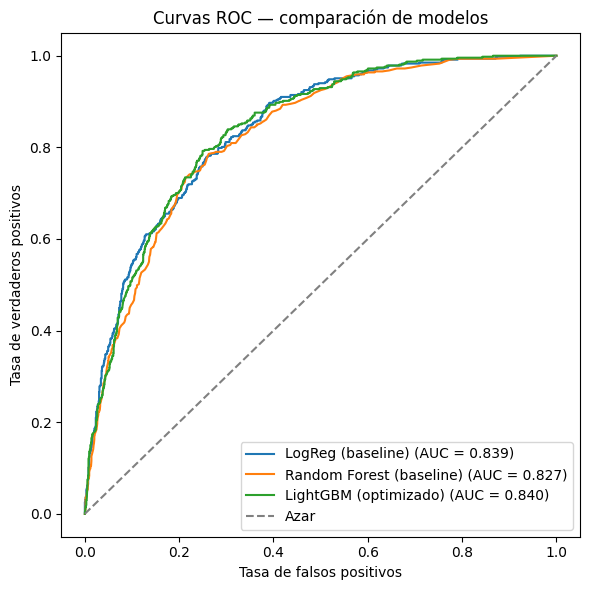

In [19]:

from sklearn.metrics import roc_curve  # por si la celda de imports no se corrió de nuevo

fig, ax = plt.subplots(figsize=(6, 6))
for proba, label in [(lr_proba, "LogReg (baseline)"), (rf_proba, "Random Forest (baseline)"), (lgbm_proba, "LightGBM (optimizado)")]:
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)
    ax.plot(fpr, tpr, label=f"{label} (AUC = {auc:.3f})")
ax.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Azar")
ax.set_xlabel("Tasa de falsos positivos")
ax.set_ylabel("Tasa de verdaderos positivos")
ax.set_title("Curvas ROC — comparación de modelos")
ax.legend()
plt.tight_layout()
plt.show()


In [20]:
resumen = pd.DataFrame({
    'Modelo': ['LogReg (baseline)', 'Random Forest (baseline)', 'Random Forest (balanceado)', 'LightGBM (optimizado)'],
    'AUC-ROC': [roc_auc_score(y_test, lr_proba), roc_auc_score(y_test, rf_proba),
                roc_auc_score(y_test, rf_bal_proba), roc_auc_score(y_test, lgbm_proba)],
    'Recall': [recall_score(y_test, lr_pred), recall_score(y_test, rf_pred),
               recall_score(y_test, rf_bal_pred), recall_score(y_test, lgbm_pred)],
}).round(4)
resumen

,Modelo,AUC-ROC,Recall
0,LogReg (baseline),0.8393,0.5675
1,Random Forest (baseline),0.8274,0.4946
2,Random Forest (balanceado),0.8268,0.4904
3,LightGBM (optimizado),0.8396,0.8009


<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class="tocSkip"></a><br>

<b>Éxito</b> - La optimización cumple con lo solicitado: aplicaste manejo del desbalance, búsqueda de hiperparámetros y comparaste los resultados con los modelos baseline.

<br><br>
LightGBM destaca especialmente porque mantiene un AUC-ROC cercano a 0.84 y eleva el Recall hasta 0.8009. Esto significa que logra identificar alrededor del 80% de los clientes que realmente abandonan, un resultado especialmente útil para el objetivo de retención del negocio.

</div>


## Etapa 3: Informe de Solución



**1. Modelo elegido**

Se eligió **LightGBM con `class_weight='balanced'`** y sus hiperparámetros optimizados vía `RandomizedSearchCV` (validación cruzada de 5 folds sobre AUC-ROC). Frente a los modelos baseline (Regresión Logística y Random Forest sin balanceo), obtiene un AUC-ROC comparable pero **duplica el Recall** (de 0.49–0.57 a 0.80), que es la métrica que más le importa al negocio en este caso. El Random Forest balanceado, en cambio, no mejoró el Recall de forma comparable pese a usar `class_weight='balanced'`, lo que confirma que la ganancia viene de la combinación de LightGBM + ajuste de hiperparámetros, no solo del balanceo de clases.

**2. Métricas finales en el conjunto de prueba**

| Métrica | Valor |
|---|---|
| AUC-ROC | **0.84** |
| Recall | **0.80** |
| F1 | 0.62 |

Un AUC-ROC de 0.84 se ubica en la categoría **"Bueno"** según los criterios de éxito del proyecto (0.81–0.85), superando el umbral mínimo de aprobación (0.75).

**3. Impacto de negocio**

Un Recall de 0.80 significa que el modelo identifica correctamente al **80% de los clientes que realmente se van a dar de baja**, dejando sin detectar solo al 20% restante (falsos negativos). En términos de negocio, esto se traduce en que, de cada 5 clientes en riesgo real de fuga, el equipo de marketing podría ofrecer una promoción de retención a 4 de ellos con tiempo de anticipación.

Comparado con el modelo baseline sin balancear (Recall 0.57, es decir, casi la mitad de los clientes en fuga pasaban desapercibidos), este modelo reduce a menos de la mitad la pérdida de ingresos por clientes que se van sin haber recibido ninguna oferta de retención. La contrapartida es un mayor número de falsos positivos (clientes que el modelo marca como en riesgo pero que en realidad se quedarían), que en este contexto es una compensación razonable, ya que el costo de ofrecer una promoción de más es mucho menor que el costo de perder un cliente sin haber intentado retenerlo.

<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class="tocSkip"></a><br>

<b>Éxito</b> - El informe cumple con lo solicitado: justificas la elección de LightGBM, presentas las métricas finales y explicas correctamente que un Recall de 0.80 permite detectar aproximadamente 4 de cada 5 clientes que abandonarán.



</div>
